In [1]:
!pip install segment-anything opencv-python matplotlib torch torchvision



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from segment_anything import sam_model_registry, SamPredictor


In [5]:
CHECKPOINT_PATH = "sam_vit_b.pth"   # path to your SAM checkpoint
MODEL_TYPE = "vit_b"

device = "cuda" if torch.cuda.is_available() else "cpu"

sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH)
sam.to(device)

predictor = SamPredictor(sam)


(np.float64(-0.5), np.float64(3503.5), np.float64(2335.5), np.float64(-0.5))

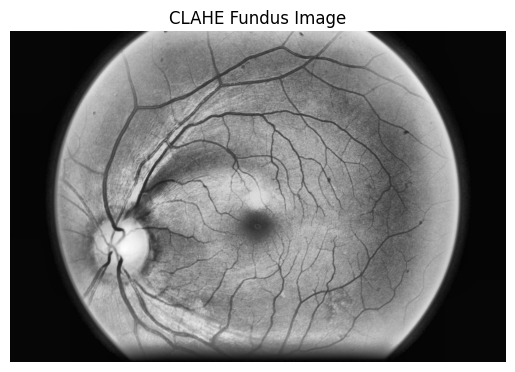

In [7]:
image_path = "clahe.jpg"

# OpenCV loads in BGR
image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("CLAHE Fundus Image")
plt.axis("off")


In [8]:
predictor.set_image(image_rgb)


In [9]:
# Example points (you must adjust for your image)
# Format: [x, y]
input_points = np.array([
    [400, 120],   # inside RNFL
    [450, 140],   # inside RNFL
])

input_labels = np.array([1, 1])  # 1 = foreground


In [10]:
input_points = np.array([
    [400, 120],
    [450, 140],
    [420, 300]    # background
])

input_labels = np.array([1, 1, 0])


In [11]:
masks, scores, logits = predictor.predict(
    point_coords=input_points,
    point_labels=input_labels,
    multimask_output=True
)

best_mask = masks[np.argmax(scores)]


(np.float64(-0.5), np.float64(3503.5), np.float64(2335.5), np.float64(-0.5))

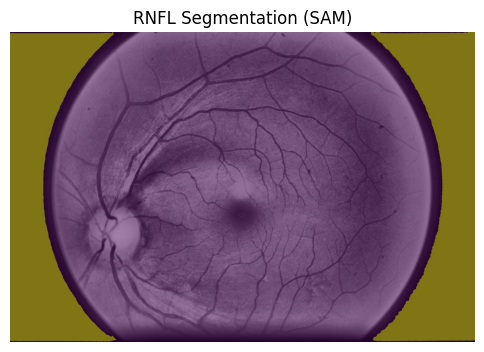

In [17]:
plt.figure(figsize=(6,6))
plt.imshow(image_rgb)
plt.imshow(best_mask, alpha=0.5)
plt.title("RNFL Segmentation (SAM)")
plt.axis("off")


In [13]:
rnfl_mask = (best_mask * 255).astype(np.uint8)
cv2.imwrite("rnfl_mask.png", rnfl_mask)


True

In [19]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from segment_anything import sam_model_registry, SamPredictor


(np.float64(-0.5), np.float64(2591.5), np.float64(1943.5), np.float64(-0.5))

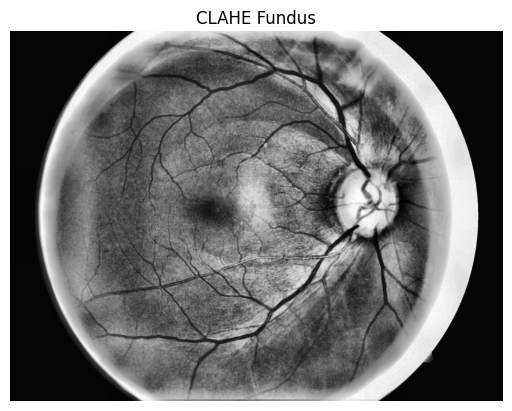

In [35]:
img_path = "clahe1.jpg"

bgr = cv2.imread(img_path)
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

plt.imshow(rgb)
plt.title("CLAHE Fundus")
plt.axis("off")


In [34]:
# Mean Shift parameters (important)
sp = 20   # spatial window
sr = 30   # color window

mean_shift = cv2.pyrMeanShiftFiltering(rgb, sp, sr)


(np.float64(-0.5), np.float64(2591.5), np.float64(1943.5), np.float64(-0.5))

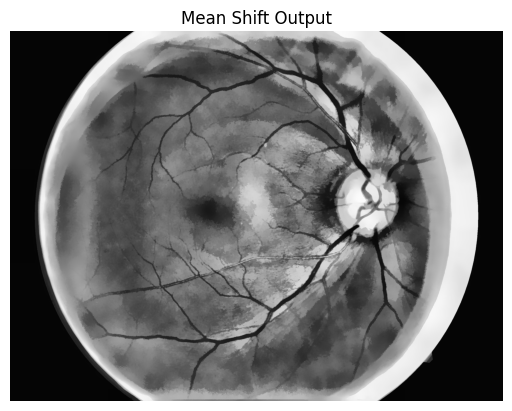

In [36]:
plt.imshow(mean_shift)
plt.title("Mean Shift Output")
plt.axis("off")


(np.float64(-0.5), np.float64(2591.5), np.float64(1943.5), np.float64(-0.5))

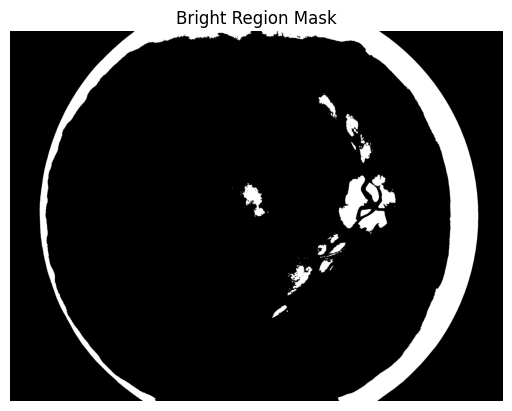

In [37]:
gray = cv2.cvtColor(mean_shift, cv2.COLOR_RGB2GRAY)

# Keep only bright pixels
_, bright_mask = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)

plt.imshow(bright_mask, cmap="gray")
plt.title("Bright Region Mask")
plt.axis("off")


In [24]:
h, w = bright_mask.shape
superior_mask = np.zeros_like(bright_mask)
superior_mask[:h//2, :] = bright_mask[:h//2, :]


(np.float64(-0.5), np.float64(2591.5), np.float64(1943.5), np.float64(-0.5))

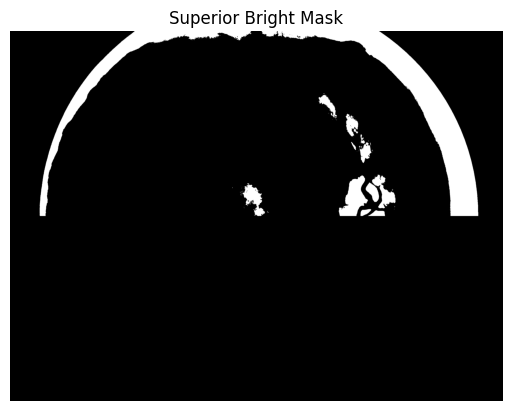

In [25]:
plt.imshow(superior_mask, cmap="gray")
plt.title("Superior Bright Mask")
plt.axis("off")


In [66]:
masks, scores, _ = predictor.predict(
    point_coords=input_points,
    point_labels=input_labels,
    multimask_output=True
)

best_mask = masks[np.argmax(scores)]


(np.float64(-0.5), np.float64(3503.5), np.float64(2335.5), np.float64(-0.5))

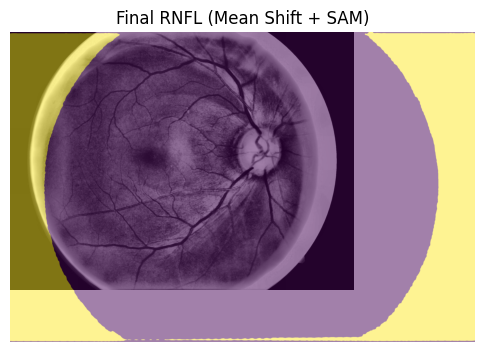

In [68]:
plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.imshow(best_mask, alpha=0.5)
plt.title("Final RNFL (Mean Shift + SAM)")
plt.axis("off")


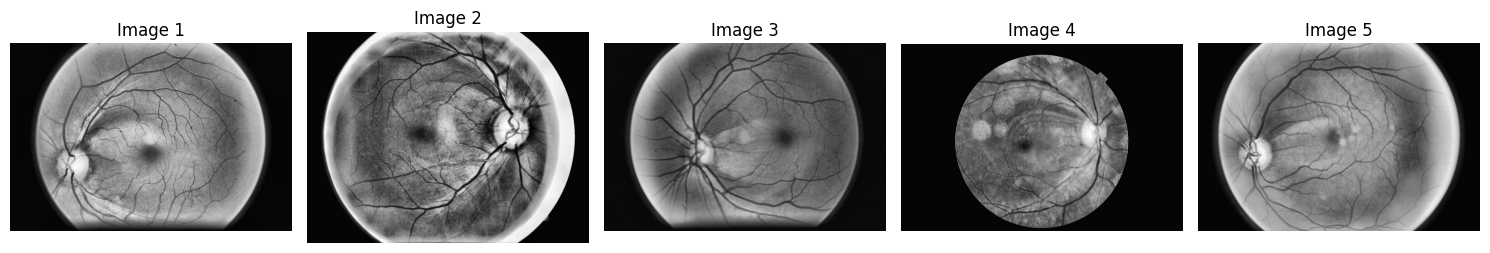

In [39]:
import cv2
import matplotlib.pyplot as plt

image_paths = [
    "clahe.jpg",
    "clahe1.jpg",
    "clahe2.jpg",
    "clahe3.jpg",
    "clahe4.jpg",
]

plt.figure(figsize=(15,6))

for i, image_path in enumerate(image_paths):
    image_bgr = cv2.imread(image_path)

    if image_bgr is None:
        print(f"❌ Cannot read {image_path}")
        continue

    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 5, i+1)
    plt.imshow(image_rgb)
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()


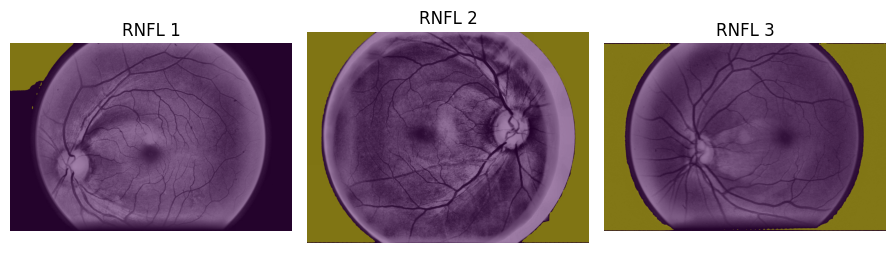

In [58]:
image_paths = [
    "clahe.jpg",
    "clahe1.jpg",
    "clahe2.jpg",
    
]

plt.figure(figsize=(15,6))

for i, image_path in enumerate(image_paths):

    # -------- STEP 4: Load image --------
    image_bgr = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

    # -------- STEP 5: Set image to SAM --------
    predictor.set_image(image_rgb)

    # -------- STEP 6: RNFL points --------
    input_points = np.array([
        [400, 120],
        [450, 140],
    ])
    input_labels = np.array([1, 1])

    # -------- STEP 7: SAM prediction --------
    masks, scores, _ = predictor.predict(
        point_coords=input_points,
        point_labels=input_labels,
        multimask_output=True
    )

    best_mask = masks[np.argmax(scores)]

    # -------- STEP 8: Visualization --------
    plt.subplot(1, 5, i+1)
    plt.imshow(image_rgb)
    plt.imshow(best_mask, alpha=0.5)
    plt.title(f"RNFL {i+1}")
    plt.axis("off")

    # -------- STEP 9: Save mask --------
    out_name = f"rnfl_mask_{i+1}.png"
    cv2.imwrite(out_name, (best_mask * 255).astype(np.uint8))

plt.tight_layout()
plt.show()


In [59]:
predictor.set_image(image_rgb)


In [60]:
# Example points (you must adjust for your image)
# Format: [x, y]
input_points = np.array([
    [400, 120],   # inside RNFL
    [450, 140],   # inside RNFL
])

input_labels = np.array([1, 1])  # 1 = foreground


In [61]:
input_points = np.array([
    [400, 120],
    [450, 140],
    [420, 300]    # background
])

input_labels = np.array([1, 1, 0])




In [62]:
masks, scores, logits = predictor.predict(
    point_coords=input_points,
    
    point_labels=input_labels,
    multimask_output=True
)

best_mask = masks[np.argmax(scores)]


(np.float64(-0.5), np.float64(3503.5), np.float64(2335.5), np.float64(-0.5))

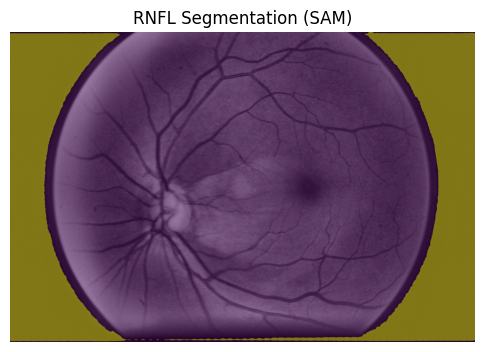

In [63]:
plt.figure(figsize=(6,6))
plt.imshow(image_rgb)
plt.imshow(best_mask, alpha=0.5)
plt.title("RNFL Segmentation (SAM)")
plt.axis("off")


In [57]:
rnfl_mask = (best_mask * 255).astype(np.uint8)
cv2.imwrite("rnfl_mask.png", rnfl_mask)


True

In [46]:
out_name = image_path.split("/")[-1].replace(".jpg", "_rnfl.png")
cv2.imwrite(out_name, rnfl_mask)


True